In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-data/final_large_crime_data.xlsx


In [2]:
df1=pd.read_excel('/kaggle/input/crime-data/final_large_crime_data.xlsx',sheet_name='Sheet1')
df1.head()

,Tweet,Crime Type,Location,Date,Time,Latitude,Longitude
0,Pickpocket caught on camera at the subway stat...,Theft,"5th Avenue, NYC",2023-12-26,20:08,30.058716,-74.723491
1,Police investigating a burglary in Lincoln Park.,Theft,"Hollywood Blvd, LA",2023-12-09,10:51,33.695992,-90.244318
2,Car break-in reported near Central Park. Stay ...,Theft,"Central Park, NY",2023-07-27,01:39,38.025847,-88.550279
3,Police investigating a burglary in Lincoln Park.,Theft,"Times Square, NYC",2023-01-11,18:44,29.058589,-79.691677
4,Car break-in reported near Central Park. Stay ...,Theft,"Main Street, Boston",2023-10-11,12:14,30.957110,-112.040227


In [3]:
df1.shape

(497, 7)

In [4]:
df1.columns

Index(['Tweet', 'Crime Type', 'Location', 'Date', 'Time', 'Latitude',
       'Longitude'],
      dtype='object')

In [5]:
df1['Crime Type'].nunique()

7

In [6]:
df1['Crime Type'].value_counts()

Crime Type
Theft                71
Assault              71
Murder               71
Arson                71
Domestic Violence    71
Fraud                71
Other                71
Name: count, dtype: int64

In [7]:
crime_types = []
for _,j in df1.iterrows():
  if j['Crime Type'] == 'Theft':
    crime_types.append(0)
  elif j['Crime Type'] == 'Assault':
    crime_types.append(1)
  elif j['Crime Type'] == 'Murder':
    crime_types.append(2)
  elif j['Crime Type'] == 'Arson':
    crime_types.append(3)
  elif j['Crime Type'] == 'Domestic Violence':
    crime_types.append(4)
  elif j['Crime Type'] == 'Fraud':
    crime_types.append(5)
  else:
    crime_types.append(6)

In [8]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
import re
df1['transformed_tweet'] = df1['Tweet'].apply(lambda x: re.sub(r'^RT[\s]+', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'@[\w]*', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'https?:\/\/.*[\r\n]*', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'#', '', x))
df1['transformed_tweet'] = df1['transformed_tweet'].apply(lambda x: re.sub(r'[0-9]', '', x))


In [10]:
df1.head()

,Tweet,Crime Type,Location,Date,Time,Latitude,Longitude,transformed_tweet
0,Pickpocket caught on camera at the subway stat...,Theft,"5th Avenue, NYC",2023-12-26,20:08,30.058716,-74.723491,Pickpocket caught on camera at the subway stat...
1,Police investigating a burglary in Lincoln Park.,Theft,"Hollywood Blvd, LA",2023-12-09,10:51,33.695992,-90.244318,Police investigating a burglary in Lincoln Park.
2,Car break-in reported near Central Park. Stay ...,Theft,"Central Park, NY",2023-07-27,01:39,38.025847,-88.550279,Car break-in reported near Central Park. Stay ...
3,Police investigating a burglary in Lincoln Park.,Theft,"Times Square, NYC",2023-01-11,18:44,29.058589,-79.691677,Police investigating a burglary in Lincoln Park.
4,Car break-in reported near Central Park. Stay ...,Theft,"Main Street, Boston",2023-10-11,12:14,30.957110,-112.040227,Car break-in reported near Central Park. Stay ...


In [11]:
df1.to_csv('crime_data1.csv',index=False)

In [12]:
df1['crime_types'] = crime_types

In [13]:
X = df1['transformed_tweet'].fillna('')  # Handle missing values
y = df1['crime_types']

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# Tokenize text data
max_vocab_size = 5000  # Maximum number of words to keep in the vocabulary
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


In [16]:

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [17]:

max_sequence_length = 100  # Set maximum length for sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post', truncating='post')

In [18]:
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Verify shapes
print(f"Training data shape: {X_train_padded.shape}")
print(f"Test data shape: {X_test_padded.shape}")

Training data shape: (397, 100)
Test data shape: (100, 100)


In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense

# Define parameters
embedding_dim = 50  # Dimension of the embedding layer
num_classes = y.nunique()  # Number of unique classes

# Build the CNN model
model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_sequence_length),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Multiclass classification uses softmax
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32
)

# Save the model
model.save('crime_classification_cnn.h5')

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5572 - loss: 1.9129 - val_accuracy: 0.9300 - val_loss: 1.8059
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9939 - loss: 1.7412 - val_accuracy: 1.0000 - val_loss: 1.5617
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.4160 - val_accuracy: 1.0000 - val_loss: 1.0986
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.8785 - val_accuracy: 1.0000 - val_loss: 0.5203
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.3434 - val_accuracy: 1.0000 - val_loss: 0.1491
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0824 - val_accuracy: 1.0000 - val_loss: 0.0451
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0258 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 0.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


df1 = pd.read_excel('/kaggle/input/crime-data/final_large_crime_data.xlsx', sheet_name='Sheet1')

X = df1[['Latitude', 'Longitude']].dropna()






In [21]:
# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:

kmeans = KMeans(n_clusters=5, random_state=42)
df1['Cluster'] = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


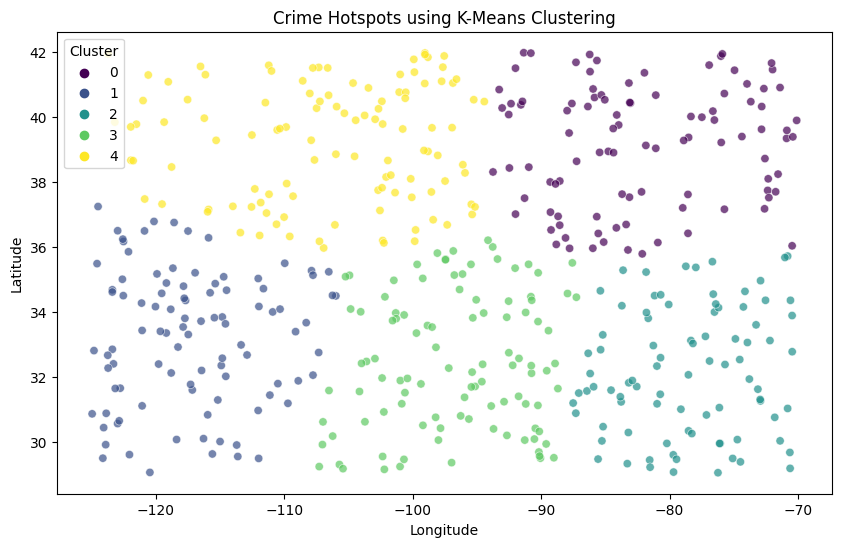

In [23]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df1['Longitude'], y=df1['Latitude'], hue=df1['Cluster'], palette='viridis', alpha=0.7)
plt.title("Crime Hotspots using K-Means Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster")
plt.show()

In [24]:

dbscan = DBSCAN(eps=0.3, min_samples=5)
df1['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

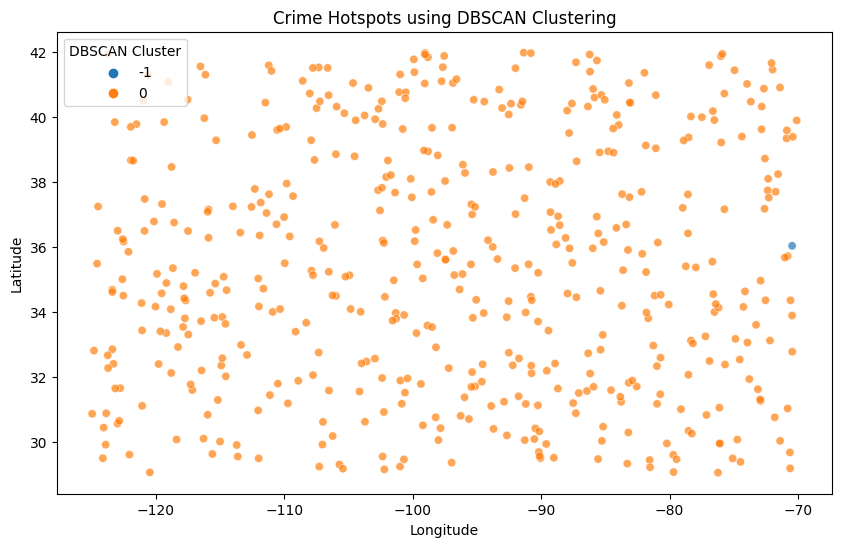

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df1['Longitude'], y=df1['Latitude'], hue=df1['DBSCAN_Cluster'], palette='tab10', alpha=0.7)
plt.title("Crime Hotspots using DBSCAN Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="DBSCAN Cluster")
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


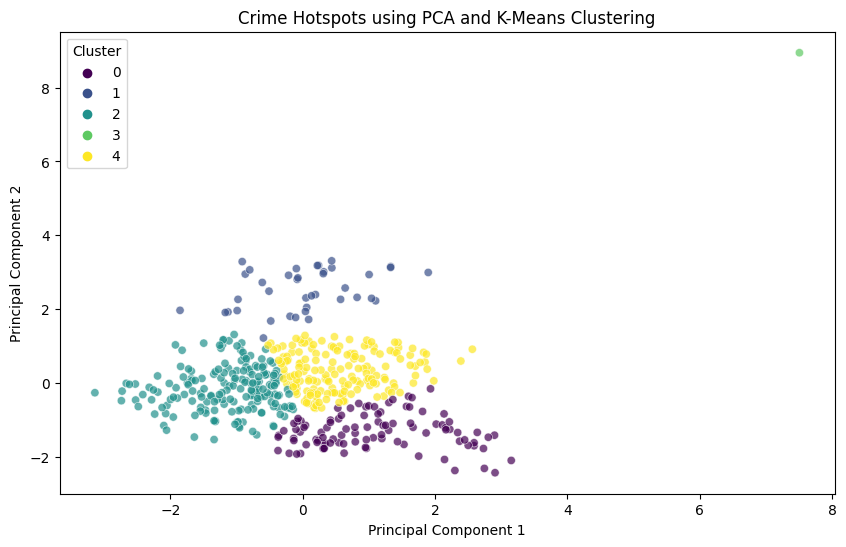

In [26]:
from sklearn.decomposition import PCA
# Drop rows with missing values
df1 = df1.dropna()

# Convert categorical features using One-Hot Encoding
categorical_cols = ['Crime Type', 'Location']
df_encoded = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)

# Convert Date and Time into numerical features
df_encoded['Date'] = pd.to_datetime(df_encoded['Date']).astype(int) / 10**9  # Convert to Unix timestamp
df_encoded['Time'] = pd.to_datetime(df_encoded['Time'], format='%H:%M').dt.hour  # Use only hour for clustering

# Extract Features (excluding the original text tweets)
X = df_encoded.drop(columns=['Tweet'])

# Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results to DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df_pca['Cluster'] = kmeans.fit_predict(X_pca)

# Plot PCA results with clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['Cluster'], palette='viridis', alpha=0.7)
plt.title("Crime Hotspots using PCA and K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

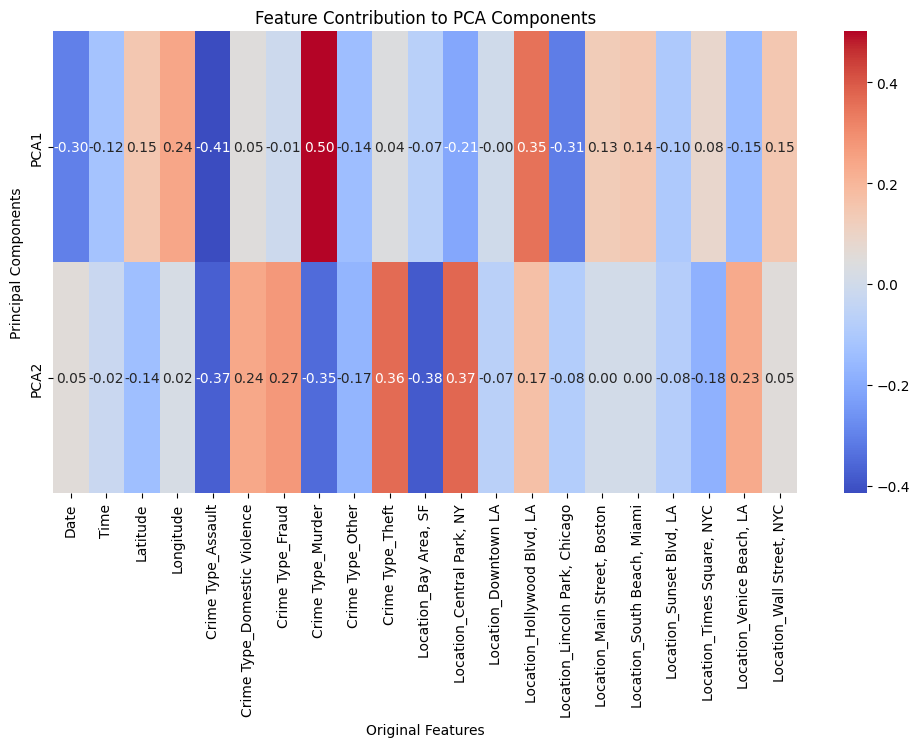

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df1 = pd.read_excel('/kaggle/input/crime-data/final_large_crime_data.xlsx', sheet_name='Sheet1')

# Drop rows with missing values
df1 = df1.dropna()

# Convert categorical features using One-Hot Encoding
categorical_cols = ['Crime Type', 'Location']
df_encoded = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)

# Convert Date and Time into numerical features
df_encoded['Date'] = pd.to_datetime(df_encoded['Date']).astype(int) / 10**9  # Convert to Unix timestamp
df_encoded['Time'] = pd.to_datetime(df_encoded['Time'], format='%H:%M').dt.hour  # Extract hour

# Extract Features
X = df_encoded.drop(columns=['Tweet'])

# Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Keep 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA Loadings
pca_loadings = pd.DataFrame(pca.components_, columns=X.columns, index=['PCA1', 'PCA2'])

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.heatmap(pca_loadings, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Contribution to PCA Components")
plt.xlabel("Original Features")
plt.ylabel("Principal Components")
plt.show()